In [3]:
#Download the S&P 500 data 

from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

sp500 = pd.read_html(
    url,
    storage_options={
        "User-Agent": "Mozilla/5.0"
    }
)[0]


sp500["Symbol"] = sp500["Symbol"].str.replace(".", "-",)
symbols_list = sp500["Symbol"].unique().tolist()
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=365 * 8)

df = yf.download(
    symbols_list,
    start=start_date,
    end=end_date,
    auto_adjust=False
).stack()


df


[*********************100%***********************]  503 of 503 completed


Price               Adj Close       Close        High         Low        Open  \
Date       Ticker                                                               
2018-06-18 A        61.187675   64.970001   65.540001   64.529999   65.480003   
           AAPL     44.470104   47.185001   47.305000   46.799999   46.970001   
           ABBV     70.033752   98.480003   99.330002   98.309998   99.150002   
           ABNB           NaN         NaN         NaN         NaN         NaN   
           ABT      54.487343   62.820000   62.869999   62.279999   62.590000   
...                       ...         ...         ...         ...         ...   
2026-06-12 XYZ      69.519997   69.519997   70.150002   68.680000   69.750000   
           YUM     154.309998  154.309998  155.100006  153.009995  154.559998   
           ZBH      88.570000   88.570000   88.779999   86.919998   87.160004   
           ZBRA    228.419998  228.419998  228.770004  220.710007  222.750000   
           ZTS      79.570000   79.570000   82.400002   79.169998   82.349998   

Price                  Volume  
Date       Ticker              
2018-06-18 A        2563100.0  
           AAPL    73939600.0  
           ABBV     6425600.0  
           ABNB           NaN  
           ABT      3672700.0  
...                       ...  
2026-06-12 XYZ      4631500.0  
           YUM      1654000.0  
           ZBH      1784500.0  
           ZBRA      584200.0  
           ZTS      6557600.0  

[1010024 rows x 6 columns]

In [4]:
#TECHNICAL INDICATORS#

df['Garman_Klass_Volatility']=0.5 * np.log(df["High"] / df["Low"]) ** 2 - (2 * np.log(2) - 1) * np.log(df["Close"] / df["Open"]) ** 2

  #RSI#

def rsi(series, period=20):
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / avg_loss

    return 100 - (100 / (1 + rs))

df['RSI'] = df.groupby(level=1)['Adj Close'].transform(
    lambda x: rsi(x, period=20)
)

#Bollinger Bands#

def bollinger_bands(series, window=20, num_std=2):
    middle = np.log1p(series).rolling(window).mean()
    std = np.log1p(series).rolling(window).std()

    upper = middle + num_std * std
    lower = middle - num_std * std

    return lower, middle, upper

df['bb_low'] = df.groupby(level=1)['Adj Close'].transform(
    lambda x: bollinger_bands(x)[0]
)

df['bb_mid'] = df.groupby(level=1)['Adj Close'].transform(
    lambda x: bollinger_bands(x)[1]
)

df['bb_high'] = df.groupby(level=1)['Adj Close'].transform(
    lambda x: bollinger_bands(x)[2]
)

#Average True Range (ATR)#

def compute_atr(stock_data, period=14):

    high = stock_data['High']
    low = stock_data['Low']
    close = stock_data['Close']

    prev_close = close.shift(1)

    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)

    atr = tr.rolling(period).mean()

    return (atr - atr.mean()) / atr.std()

df['ATR'] = (
    df.groupby(level=1, group_keys=False)
      .apply(compute_atr)
)

#MACD#

def compute_macd(close):

    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()

    macd = ema12 - ema26

    return (macd - macd.mean()) / macd.std()

df['MACD'] = (
    df.groupby(level=1, group_keys=False)['Adj Close']
      .apply(compute_macd)
)

#Dollar Volume

df['Dollar_Volume'] = df['Adj Close'] * df['Volume']/1e6

df
 

Price               Adj Close       Close        High         Low        Open  \
Date       Ticker                                                               
2018-06-18 A        61.187675   64.970001   65.540001   64.529999   65.480003   
           AAPL     44.470104   47.185001   47.305000   46.799999   46.970001   
           ABBV     70.033752   98.480003   99.330002   98.309998   99.150002   
           ABNB           NaN         NaN         NaN         NaN         NaN   
           ABT      54.487343   62.820000   62.869999   62.279999   62.590000   
...                       ...         ...         ...         ...         ...   
2026-06-12 XYZ      69.519997   69.519997   70.150002   68.680000   69.750000   
           YUM     154.309998  154.309998  155.100006  153.009995  154.559998   
           ZBH      88.570000   88.570000   88.779999   86.919998   87.160004   
           ZBRA    228.419998  228.419998  228.770004  220.710007  222.750000   
           ZTS      79.570000   79.570000   82.400002   79.169998   82.349998   

Price                  Volume  Garman_Klass_Volatility        RSI    bb_low  \
Date       Ticker                                                             
2018-06-18 A        2563100.0                 0.000097        NaN       NaN   
           AAPL    73939600.0                 0.000050        NaN       NaN   
           ABBV     6425600.0                 0.000036        NaN       NaN   
           ABNB           NaN                      NaN        NaN       NaN   
           ABT      3672700.0                 0.000039        NaN       NaN   
...                       ...                      ...        ...       ...   
2026-06-12 XYZ      4631500.0                 0.000220  47.002679  4.197740   
           YUM      1654000.0                 0.000091  57.255551  4.989627   
           ZBH      1784500.0                 0.000125  65.242003  4.410895   
           ZBRA      584200.0                 0.000399  36.432615  5.397452   
           ZTS      6557600.0                 0.000344  58.758026  4.334891   

Price                bb_mid   bb_high       ATR      MACD  Dollar_Volume  
Date       Ticker                                                         
2018-06-18 A            NaN       NaN       NaN -0.096363     156.830131  
           AAPL         NaN       NaN       NaN -0.301337    3288.101718  
           ABBV         NaN       NaN       NaN -0.232951     450.008880  
           ABNB         NaN       NaN       NaN       NaN            NaN  
           ABT          NaN       NaN       NaN -0.083334     200.115664  
...                     ...       ...       ...       ...            ...  
2026-06-12 XYZ     4.269761  4.341781 -0.522784 -0.055873     321.981864  
           YUM     5.021974  5.054321  1.156262 -0.562770     255.228736  
           ZBH     4.459688  4.508481 -0.538419  0.285195     158.053164  
           ZBRA    5.498129  5.598805  0.280664 -0.310746     133.442963  
           ZTS     4.382638  4.430385 -0.909337 -1.521600     521.788230  

[1010024 rows x 14 columns]

In [5]:
#Filtering the top 150 stocks by Dollar Volume and keeping only the technical indicators

last_cols=['Adj Close','Garman_Klass_Volatility', 'RSI', 'bb_low', 'bb_mid', 'bb_high', 'ATR', 'MACD']
data = pd.concat([
    df.unstack('Ticker')['Dollar_Volume'].resample('ME').mean().stack('Ticker').to_frame('Dollar_Volume'),
    df.unstack('Ticker')[last_cols].resample('ME').mean().stack('Ticker')
], axis=1)

data


Dollar_Volume   Adj Close  Garman_Klass_Volatility  \
Date       Ticker                                                       
2018-06-30 A          182.475419   58.820027                 0.000158   
           AAPL      4312.317240   43.652047                 0.000125   
           ABBV       433.427251   67.241769                 0.000152   
           ABNB              NaN         NaN                      NaN   
           ABT        264.242673   53.370180                 0.000092   
...                          ...         ...                      ...   
2026-06-30 XYZ        388.611436   70.253999                 0.000707   
           YUM        325.141136  149.914000                 0.000199   
           ZBH        177.417969   86.647000                 0.000272   
           ZBRA       222.328046  236.617999                 0.000915   
           ZTS        530.054499   79.377999                 0.000380   

                         RSI    bb_low    bb_mid   bb_high       ATR      MACD  
Date       Ticker                                                               
2018-06-30 A             NaN       NaN       NaN       NaN       NaN -0.315822  
           AAPL          NaN       NaN       NaN       NaN       NaN -0.362658  
           ABBV          NaN       NaN       NaN       NaN       NaN -0.487130  
           ABNB          NaN       NaN       NaN       NaN       NaN       NaN  
           ABT           NaN       NaN       NaN       NaN       NaN -0.238601  
...                      ...       ...       ...       ...       ...       ...  
2026-06-30 XYZ     48.014575  4.210951  4.278476  4.346002 -0.577657  0.125902  
           YUM     45.569475  4.990555  5.022006  5.053457  0.998377 -1.206246  
           ZBH     60.456433  4.402995  4.445762  4.488529 -0.542005 -0.101057  
           ZBRA    51.482944  5.412271  5.505692  5.599114  0.292342  0.254821  
           ZTS     39.515060  4.281051  4.386420  4.491789 -0.771081 -2.267886  

[48791 rows x 9 columns]

In [ ]:
#Filtering the top 150 stocks by Dollar Volume and keeping only the technical indicators

data['Dollar_Volume'] = (
    data.loc[:, 'Dollar_Volume']
    .unstack('Ticker')
    .rolling(5*12,min_periods=12)
    .mean()
    .stack('Ticker')
)

data['Dollar_Volume_Rank'] = (
    data.groupby(level=0)['Dollar_Volume']
    .rank(ascending=False)
)

data = data[data['Dollar_Volume_Rank'] <= 150] \
           .drop(['Dollar_Volume', 'Dollar_Volume_Rank'], axis=1)

data

Adj Close  Garman_Klass_Volatility        RSI    bb_low  \
Date       Ticker                                                             
2019-05-31 AAPL     45.692750                 0.000222  43.444523  3.812674   
           ABBV     58.685622                 0.000168  44.591496  4.063725   
           ABT      67.654578                 0.000123  46.483529  4.194834   
           ACN     160.155534                 0.000096  46.904735  5.056452   
           ADBE    277.341820                 0.000171  53.137588  5.589940   
...                       ...                      ...        ...       ...   
2026-06-30 WDC     541.699585                 0.002003  60.579427  6.084188   
           WFC      80.991001                 0.000192  61.075400  4.290121   
           WMT     118.200999                 0.000195  33.539454  4.713187   
           XOM     149.831999                 0.000196  50.361566  4.966000   
           XYZ      70.253999                 0.000707  48.014575  4.210951   

                     bb_mid   bb_high       ATR      MACD  
Date       Ticker                                          
2019-05-31 AAPL    3.883793  3.954913 -1.178633 -0.334695  
           ABBV    4.092789  4.121854 -0.987639 -0.303273  
           ABT     4.234498  4.274162 -0.863943 -0.189097  
           ACN     5.087078  5.117703 -1.268556  0.161280  
           ADBE    5.629844  5.669749 -1.046843  0.229063  
...                     ...       ...       ...       ...  
2026-06-30 WDC     6.229291  6.374394  5.551994  5.545239  
           WFC     4.354857  4.419594  0.838337  0.288239  
           WMT     4.824400  4.935612  3.111759 -3.750275  
           XOM     5.028571  5.091141  2.190509 -0.673600  
           XYZ     4.278476  4.346002 -0.577657  0.125902  

[12900 rows x 8 columns]

In [ ]:
#Calculating and normalizing the returns in different timeframes

def cal_returns(df):
    outlier_cutoff = 0.05

    lags = [1,2, 3, 6, 9, 12] 

    for lag in lags:
        df[f'return_{lag}m'] = (df['Adj Close']
                                .pct_change(lag)
                                .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                        upper=x.quantile(1 - outlier_cutoff)))
                                 .add(1)
                                .pow(1 / lag)
                                .sub(1)).dropna()
    return df

data = data.groupby(level=1, group_keys=False).apply(cal_returns)
data

Adj Close  Garman_Klass_Volatility        RSI    bb_low  \
Date       Ticker                                                             
2019-05-31 AAPL     45.692750                 0.000222  43.444523  3.812674   
           ABBV     58.685622                 0.000168  44.591496  4.063725   
           ABT      67.654578                 0.000123  46.483529  4.194834   
           ACN     160.155534                 0.000096  46.904735  5.056452   
           ADBE    277.341820                 0.000171  53.137588  5.589940   
...                       ...                      ...        ...       ...   
2026-06-30 WDC     541.699585                 0.002003  60.579427  6.084188   
           WFC      80.991001                 0.000192  61.075400  4.290121   
           WMT     118.200999                 0.000195  33.539454  4.713187   
           XOM     149.831999                 0.000196  50.361566  4.966000   
           XYZ      70.253999                 0.000707  48.014575  4.210951   

                     bb_mid   bb_high       ATR      MACD  return_1m  \
Date       Ticker                                                      
2019-05-31 AAPL    3.883793  3.954913 -1.178633 -0.334695        NaN   
           ABBV    4.092789  4.121854 -0.987639 -0.303273        NaN   
           ABT     4.234498  4.274162 -0.863943 -0.189097        NaN   
           ACN     5.087078  5.117703 -1.268556  0.161280        NaN   
           ADBE    5.629844  5.669749 -1.046843  0.229063        NaN   
...                     ...       ...       ...       ...        ...   
2026-06-30 WDC     6.229291  6.374394  5.551994  5.545239   0.117369   
           WFC     4.354857  4.419594  0.838337  0.288239   0.060648   
           WMT     4.824400  4.935612  3.111759 -3.750275  -0.054015   
           XOM     5.028571  5.091141  2.190509 -0.673600  -0.012004   
           XYZ     4.278476  4.346002 -0.577657  0.125902  -0.014546   

                   return_2m  return_3m  return_6m  return_9m  return_12m  
Date       Ticker                                                          
2019-05-31 AAPL          NaN        NaN        NaN        NaN         NaN  
           ABBV          NaN        NaN        NaN        NaN         NaN  
           ABT           NaN        NaN        NaN        NaN         NaN  
           ACN           NaN        NaN        NaN        NaN         NaN  
           ADBE          NaN        NaN        NaN        NaN         NaN  
...                      ...        ...        ...        ...         ...  
2026-06-30 WDC      0.220580   0.250619   0.441655   0.268367    0.211145  
           WFC     -0.003326   0.012222  -0.018931  -0.000184    0.007148  
           WMT     -0.034485  -0.014609   0.007249   0.016897    0.017388  
           XOM     -0.007295  -0.015360   0.042905   0.034290    0.030008  
           XYZ      0.024196   0.045815   0.016124  -0.007647    0.007421  

[12900 rows x 14 columns]

In [ ]:
#From the above data, we will now load the Fama-French factors and join them with the stock returns.

import pandas as pd
import zipfile
from io import StringIO

# =========================
# Load Fama-French factors
# =========================

with zipfile.ZipFile("F-F_Research_Data_5_Factors_2x3_CSV.zip") as z:
    txt = z.read(z.namelist()[0]).decode("utf-8")

lines = txt.splitlines()

start = next(i for i, line in enumerate(lines)
             if line.startswith(",Mkt-RF"))

end = next(i for i, line in enumerate(lines)
           if "Annual Factors" in line)

factor_data = pd.read_csv(
    StringIO("\n".join(lines[start:end])),
    index_col=0
)

factor_data = factor_data.dropna()

factor_data.index = pd.to_datetime(
    factor_data.index.astype(int).astype(str),
    format="%Y%m"
)

factor_data.index = factor_data.index + pd.offsets.MonthEnd(0)

factor_data.index.name = "Date"

factor_data = factor_data.drop("RF", axis=1)

factor_data = factor_data.astype(float).div(100)

# =========================
# Join with stock returns
# =========================

factor_data = data[['return_1m']].join(
    factor_data,
    on='Date',
    how='inner'
)

factor_data



return_1m  Mkt-RF     SMB     HML     RMW     CMA
Date       Ticker                                                   
2019-05-31 AAPL          NaN -0.0692 -0.0156 -0.0245 -0.0048  0.0176
           ABBV          NaN -0.0692 -0.0156 -0.0245 -0.0048  0.0176
           ABT           NaN -0.0692 -0.0156 -0.0245 -0.0048  0.0176
           ACN           NaN -0.0692 -0.0156 -0.0245 -0.0048  0.0176
           ADBE          NaN -0.0692 -0.0156 -0.0245 -0.0048  0.0176
...                      ...     ...     ...     ...     ...     ...
2026-04-30 WDC      0.312934  0.0994  0.0039 -0.0127 -0.0432 -0.0380
           WFC      0.044048  0.0994  0.0039 -0.0127 -0.0432 -0.0380
           WMT      0.028864  0.0994  0.0039 -0.0127 -0.0432 -0.0380
           XOM     -0.031292  0.0994  0.0039 -0.0127 -0.0432 -0.0380
           XYZ      0.090432  0.0994  0.0039 -0.0127 -0.0432 -0.0380

[12600 rows x 6 columns]

In [ ]:
#Filtering the data to only include stocks with at least 10 observations

observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >= 10]

factor_data = factor_data[
    factor_data.index.get_level_values('Ticker')
    .isin(valid_stocks.index)]

factor_data

return_1m  Mkt-RF     SMB     HML     RMW     CMA
Date       Ticker                                                   
2019-05-31 AAPL          NaN -0.0692 -0.0156 -0.0245 -0.0048  0.0176
           ABBV          NaN -0.0692 -0.0156 -0.0245 -0.0048  0.0176
           ABT           NaN -0.0692 -0.0156 -0.0245 -0.0048  0.0176
           ACN           NaN -0.0692 -0.0156 -0.0245 -0.0048  0.0176
           ADBE          NaN -0.0692 -0.0156 -0.0245 -0.0048  0.0176
...                      ...     ...     ...     ...     ...     ...
2026-04-30 WDC      0.312934  0.0994  0.0039 -0.0127 -0.0432 -0.0380
           WFC      0.044048  0.0994  0.0039 -0.0127 -0.0432 -0.0380
           WMT      0.028864  0.0994  0.0039 -0.0127 -0.0432 -0.0380
           XOM     -0.031292  0.0994  0.0039 -0.0127 -0.0432 -0.0380
           XYZ      0.090432  0.0994  0.0039 -0.0127 -0.0432 -0.0380

[12487 rows x 6 columns]

In [ ]:
#Calculating the rolling betas for each stock using the Fama-French factors

betas=(factor_data.groupby(level=1, 
                        group_keys=False) .apply(
        lambda x: RollingOLS(
            endog=x['return_1m'],
            exog=sm.add_constant(
                x.drop('return_1m', axis=1)
            ),
            window=min(24, x.shape[0]),
            min_nobs=len(x.columns) + 1
        )
        .fit(params_only=True)
        .params
        .drop('const', axis=1)
    ))
betas


Mkt-RF       SMB       HML       RMW       CMA
Date       Ticker                                                  
2019-05-31 AAPL         NaN       NaN       NaN       NaN       NaN
           ABBV         NaN       NaN       NaN       NaN       NaN
           ABT          NaN       NaN       NaN       NaN       NaN
           ACN          NaN       NaN       NaN       NaN       NaN
           ADBE         NaN       NaN       NaN       NaN       NaN
...                     ...       ...       ...       ...       ...
2026-04-30 WDC     0.514912  0.287133  0.710341 -1.428673  0.254136
           WFC     1.209182 -0.222572  0.449946  0.192699  0.205166
           WMT     0.322588 -0.080614 -0.442255  0.466096  0.617265
           XOM    -0.099036  0.073738  0.474599 -0.420696  0.918620
           XYZ     0.002796  1.700481 -1.641789 -2.164773  0.863661

[12487 rows x 5 columns]

In [ ]:
#Joining the betas with the stock data and filling missing values with the mean of each stock's beta

factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

data = data.drop(columns=factors, errors='ignore')

data = data.join(
    betas.groupby('Ticker').shift()
)

data.loc[:,factors] = data.groupby('Ticker', group_keys=False)[factors].apply(lambda x:x.fillna(x.mean()))

data= data.drop('Adj Close',axis=1,errors='ignore')

data = data.dropna()
data.info()


<class 'pandas.DataFrame'>
MultiIndex: 10565 entries, (Timestamp('2020-05-31 00:00:00'), 'AAPL') to (Timestamp('2026-06-30 00:00:00'), 'XYZ')
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Garman_Klass_Volatility  10565 non-null  float64
 1   RSI                      10565 non-null  float64
 2   bb_low                   10565 non-null  float64
 3   bb_mid                   10565 non-null  float64
 4   bb_high                  10565 non-null  float64
 5   ATR                      10565 non-null  float64
 6   MACD                     10565 non-null  float64
 7   return_1m                10565 non-null  float64
 8   return_2m                10565 non-null  float64
 9   return_3m                10565 non-null  float64
 10  return_6m                10565 non-null  float64
 11  return_9m                10565 non-null  float64
 12  return_12m               10565 non-null  float64
 13  Mkt-RF    

In [ ]:

##Clustering the stocks based on their betas using KMeans

from sklearn.cluster import KMeans

data =data.drop('Cluster',axis=1,errors='ignore')

def get_clusters(df):
    df['Cluster'] = KMeans(n_clusters=4,
                           random_state=0,
                           init=initial_centroids).fit(df).labels_
    return df

data= data.dropna().groupby(level=0, group_keys=False).apply(get_clusters)
data

Garman_Klass_Volatility        RSI    bb_low    bb_mid  \
Date       Ticker                                                           
2020-05-31 AAPL                   0.000225  69.593576  4.192762  4.274622   
           ABBV                   0.000459  65.655951  4.146893  4.216560   
           ABT                    0.000348  52.082479  4.368776  4.426522   
           ACN                    0.000196  61.861892  5.046369  5.115663   
           ADBE                   0.000275  63.603825  5.792136  5.864619   
...                                    ...        ...       ...       ...   
2026-06-30 WDC                    0.002003  60.579427  6.084188  6.229291   
           WFC                    0.000192  61.075400  4.290121  4.354857   
           WMT                    0.000195  33.539454  4.713187  4.824400   
           XOM                    0.000196  50.361566  4.966000  5.028571   
           XYZ                    0.000707  48.014575  4.210951  4.278476   

                    bb_high       ATR      MACD  return_1m  return_2m  \
Date       Ticker                                                       
2020-05-31 AAPL    4.356481 -0.835091  0.497574   0.123553   0.087925   
           ABBV    4.286227 -0.080715  0.619795   0.107752   0.071447   
           ABT     4.484268  1.014028  0.925155   0.027725   0.067259   
           ACN     5.184957 -0.227778  0.757487   0.094500   0.068451   
           ADBE    5.937103 -0.137769  0.972729   0.118298   0.074888   
...                     ...       ...       ...        ...        ...   
2026-06-30 WDC     6.374394  5.551994  5.545239   0.117369   0.220580   
           WFC     4.419594  0.838337  0.288239   0.060648  -0.003326   
           WMT     4.935612  3.111759 -3.750275  -0.054015  -0.034485   
           XOM     5.091141  2.190509 -0.673600  -0.012004  -0.007295   
           XYZ     4.346002 -0.577657  0.125902  -0.014546   0.024196   

                   return_3m  return_6m  return_9m  return_12m    Mkt-RF  \
Date       Ticker                                                          
2020-05-31 AAPL    -0.000523   0.028946   0.048024    0.042144  0.317631   
           ABBV    -0.003703   0.009901   0.039157    0.014787  0.256591   
           ABT      0.020710   0.016024   0.010193    0.016355  0.257652   
           ACN     -0.028895  -0.003325  -0.000994    0.006521  0.436966   
           ADBE     0.002748   0.037491   0.027660    0.023978  0.401292   
...                      ...        ...        ...         ...       ...   
2026-06-30 WDC      0.250619   0.441655   0.268367    0.211145  0.225136   
           WFC      0.012222  -0.018931  -0.000184    0.007148  0.454734   
           WMT     -0.014609   0.007249   0.016897    0.017388  0.233765   
           XOM     -0.015360   0.042905   0.034290    0.030008  0.100563   
           XYZ      0.045815   0.016124  -0.007647    0.007421  0.960571   

                        SMB       HML       RMW       CMA  Cluster  
Date       Ticker                                                   
2020-05-31 AAPL    0.264051 -0.442367  0.290017  0.056962        3  
           ABBV   -0.117304 -0.107196  0.181157  0.926105        0  
           ABT     0.070720 -0.016056 -0.165816  0.327059        2  
           ACN     0.179671 -0.185772  0.263417  0.422338        0  
           ADBE    0.275341 -0.262761  0.488756 -0.218937        0  
...                     ...       ...       ...       ...      ...  
2026-06-30 WDC    -0.447786  1.254418 -1.798258 -0.760590        3  
           WFC     0.112863  0.798264 -0.172976 -0.242828        2  
           WMT    -0.279443 -0.152058  0.056598  0.237134        0  
           XOM     0.345601  0.188691  0.097478  0.732235        1  
           XYZ     0.810450 -0.606555 -1.376814  0.273629        1  

[10565 rows x 19 columns]

In [23]:


def plot_clusters(data):
    
    cluster_0 = data[data['Cluster'] == 0]
    cluster_1 = data[data['Cluster'] == 1]
    cluster_2 = data[data['Cluster'] == 2]
    cluster_3 = data[data['Cluster'] == 3]

    plt.scatter(cluster_0.iloc[:, 5],cluster_0.iloc[:,1],label='Cluster_0',color='red')
    plt.scatter(cluster_1.iloc[:, 5],cluster_1.iloc[:,1],label='Cluster_1',color='blue')
    plt.scatter(cluster_2.iloc[:, 5],cluster_2.iloc[:,1],label='Cluster_2',color='green')
    plt.scatter(cluster_3.iloc[:, 5],cluster_3.iloc[:,1],label='Cluster_3',color='orange')

    plt.legend()
    plt.show()
    return

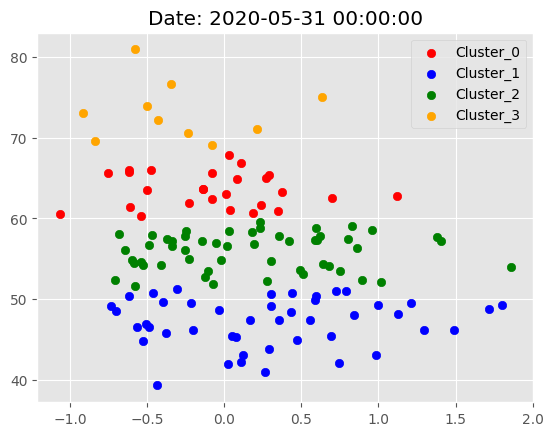

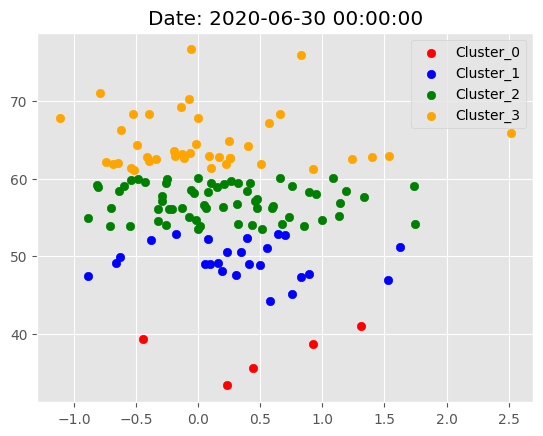

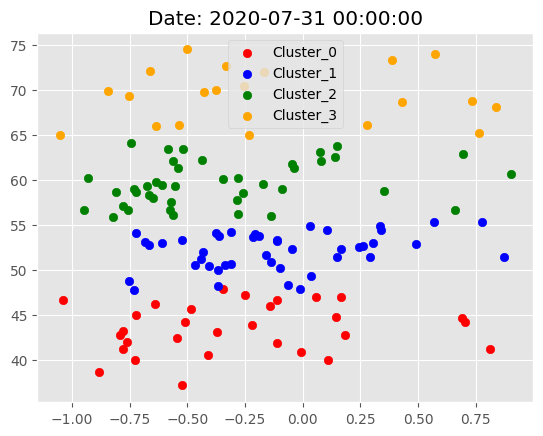

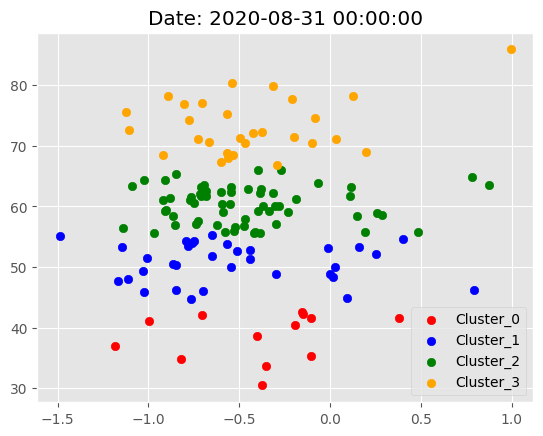

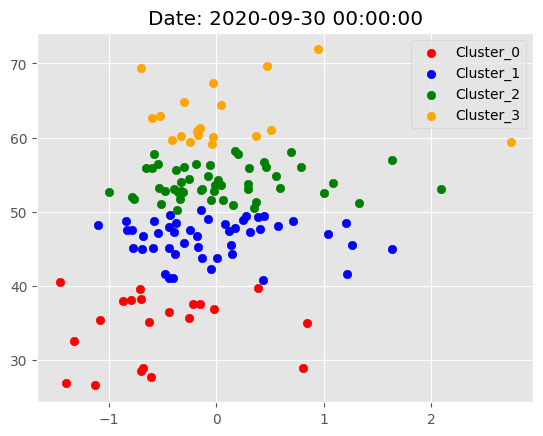

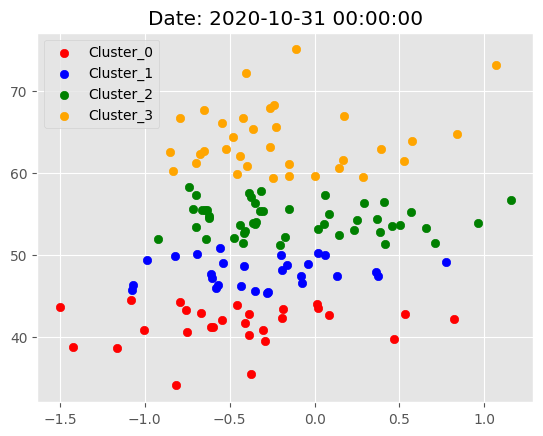

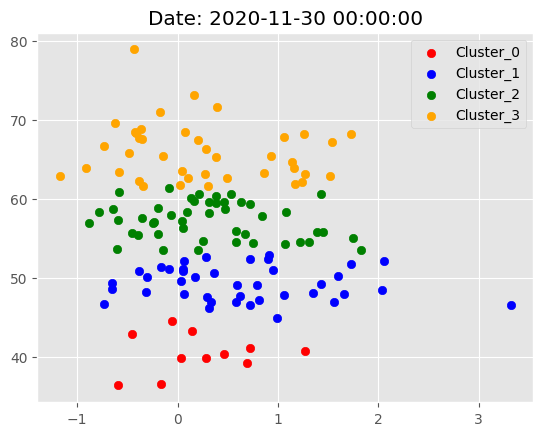

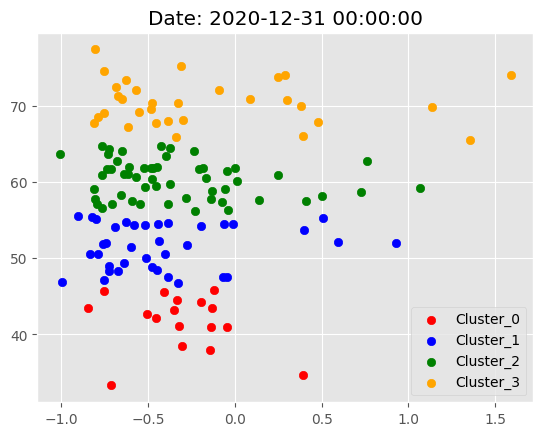

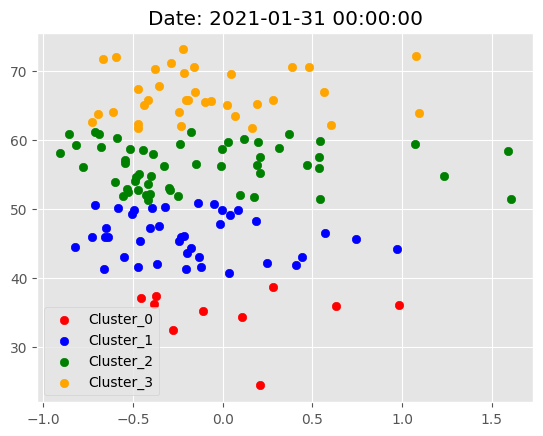

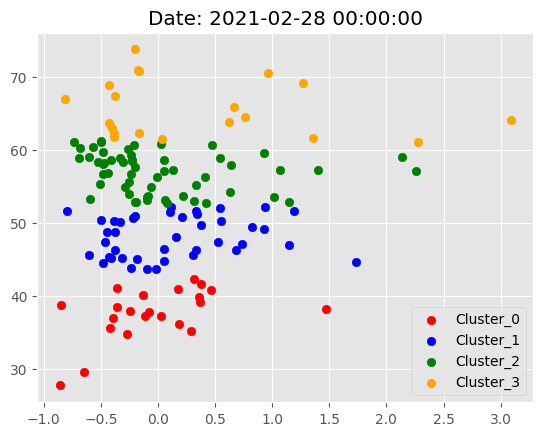

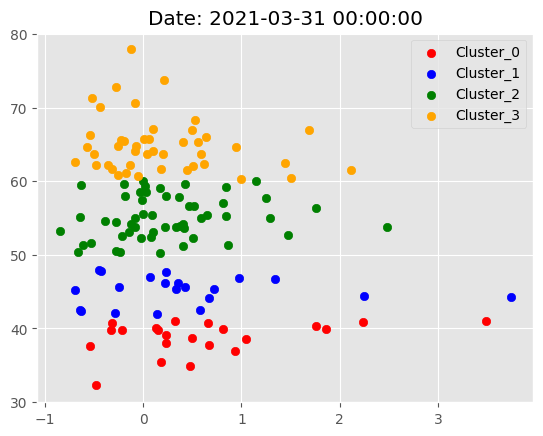

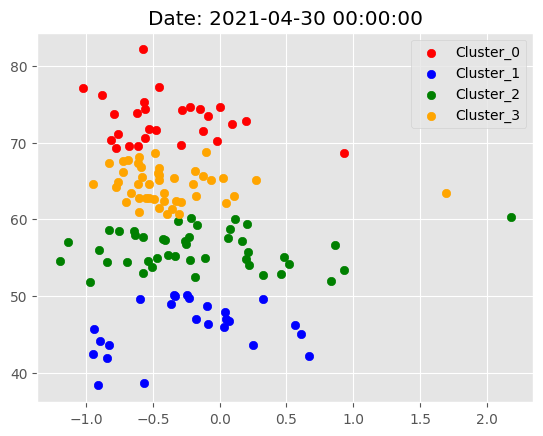

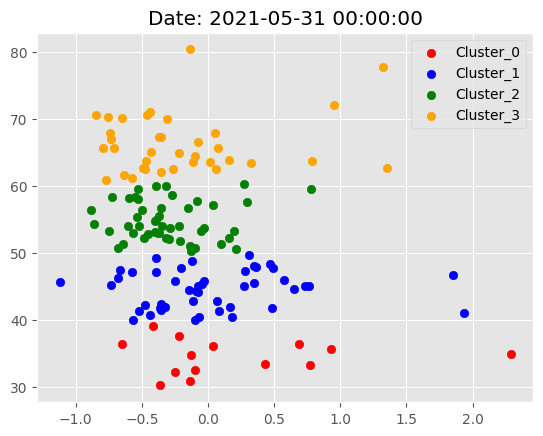

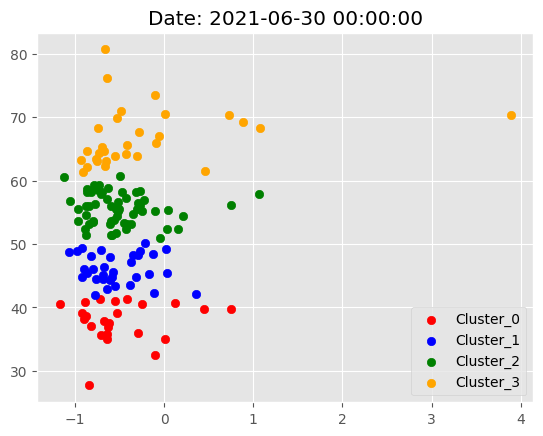

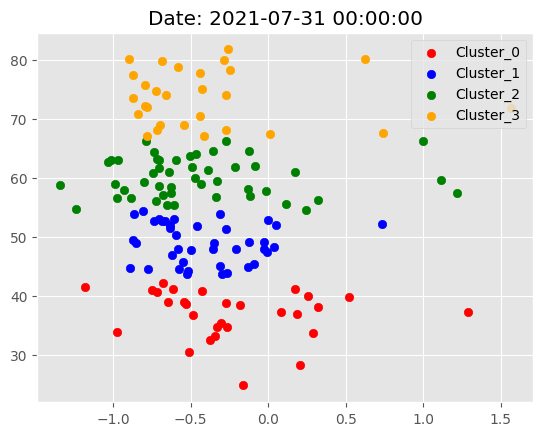

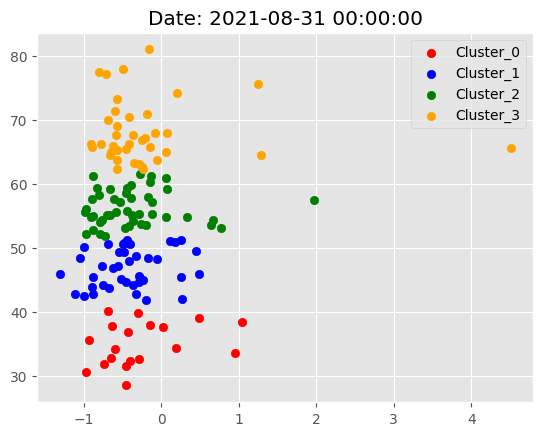

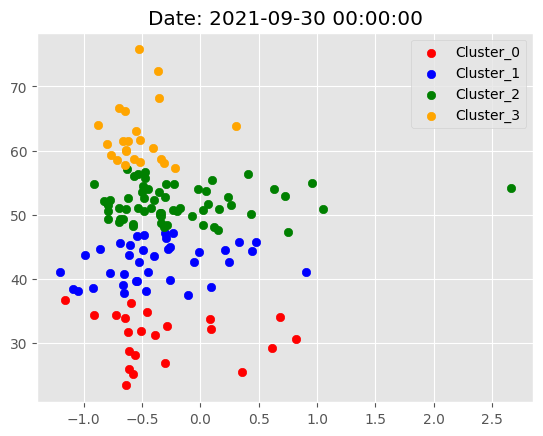

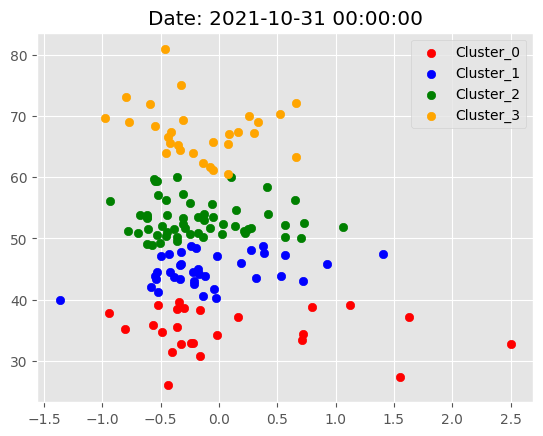

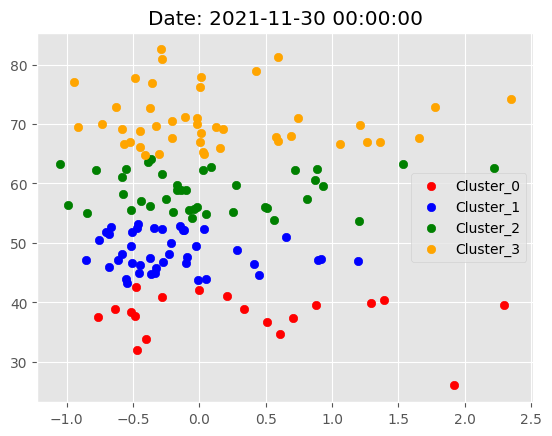

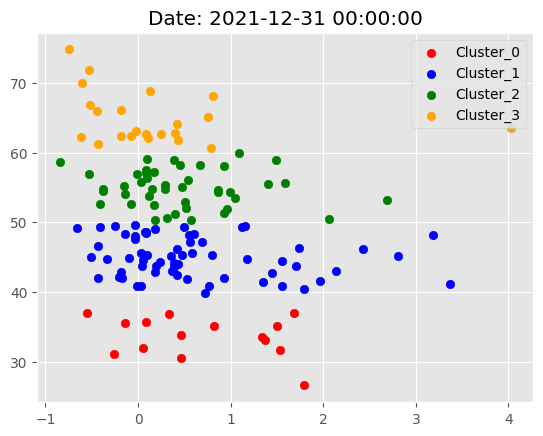

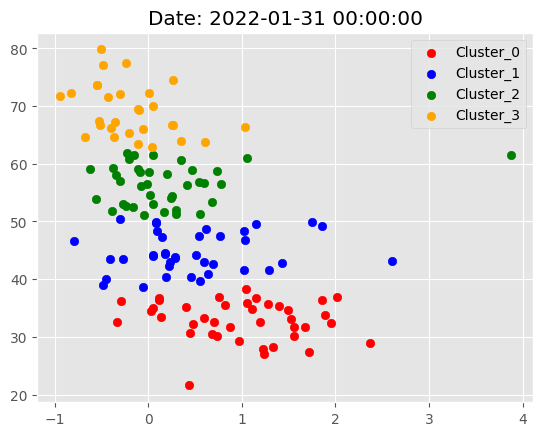

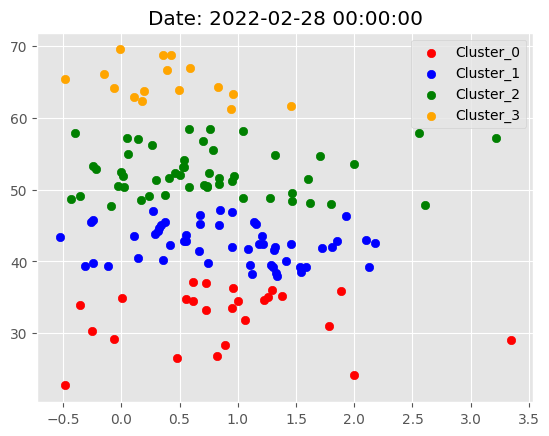

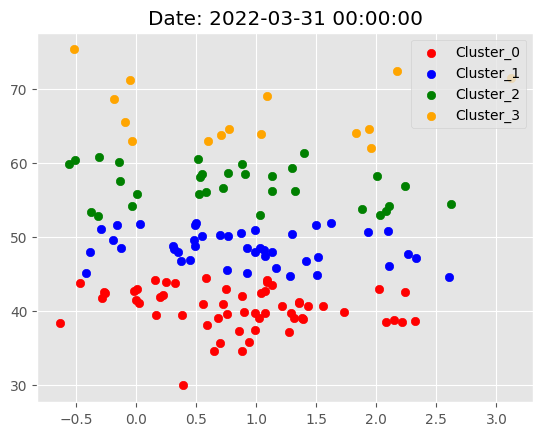

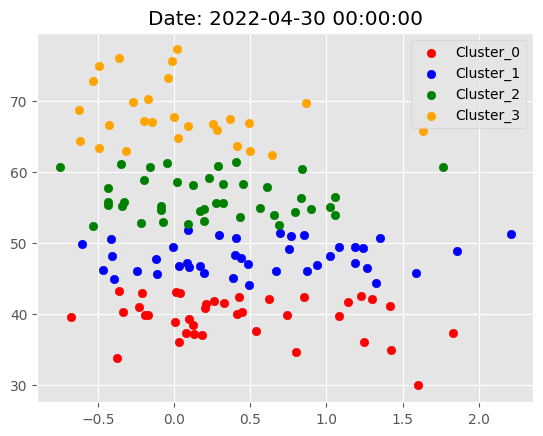

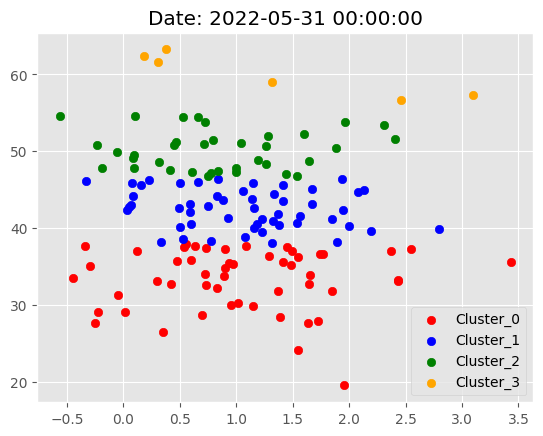

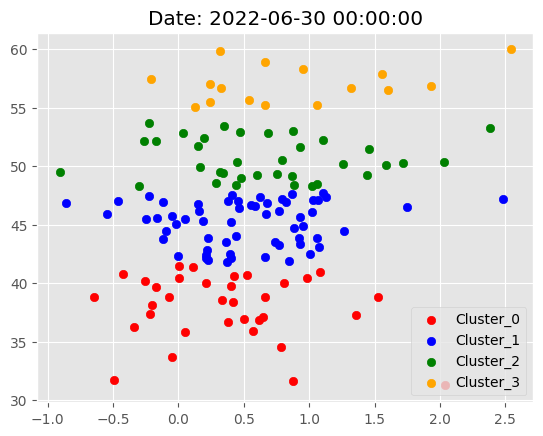

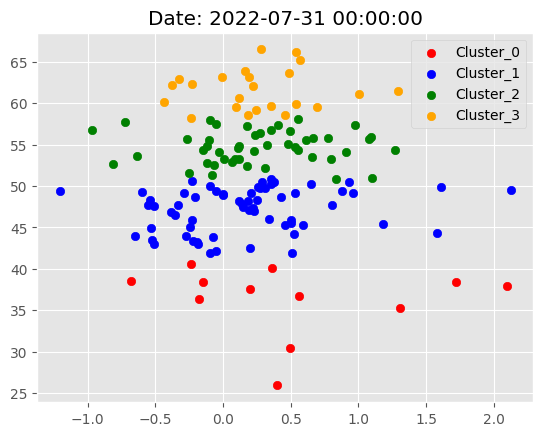

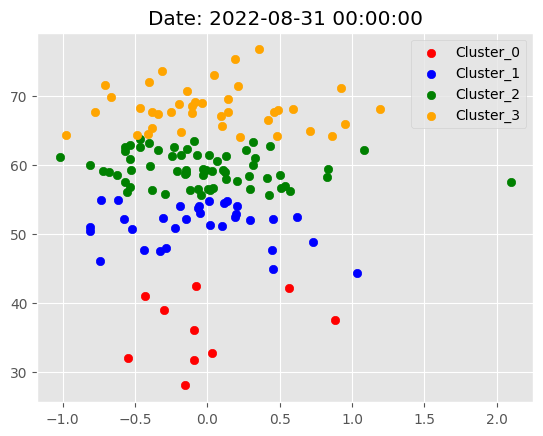

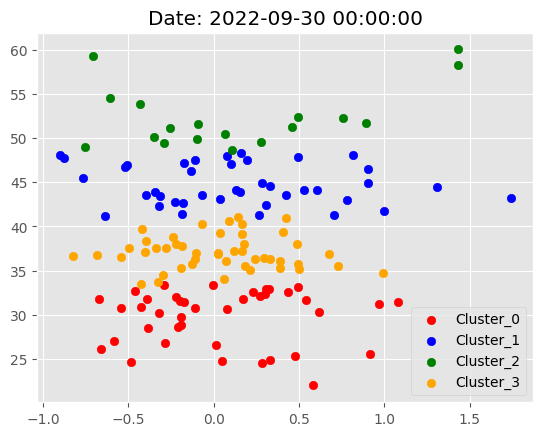

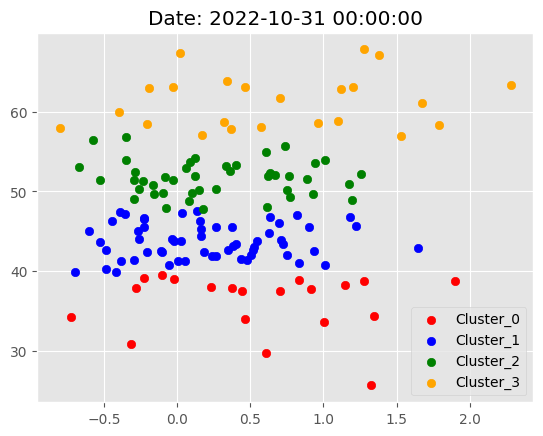

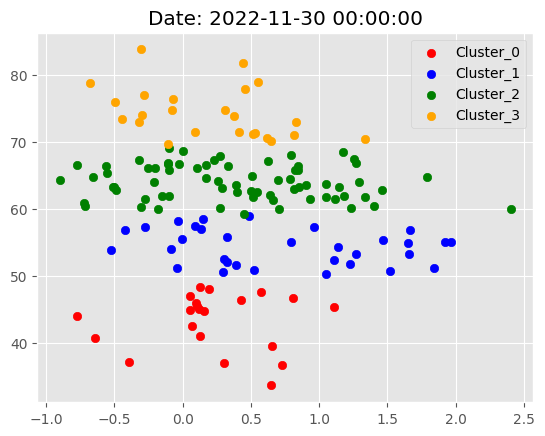

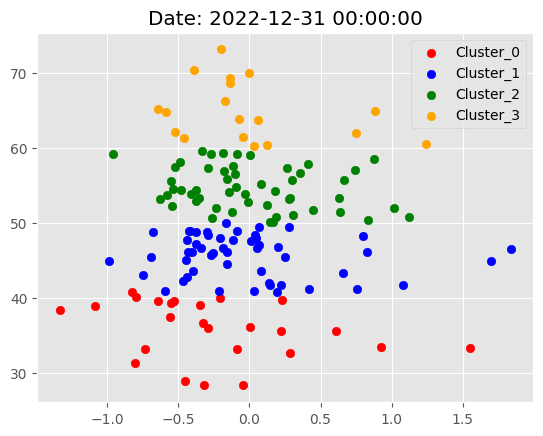

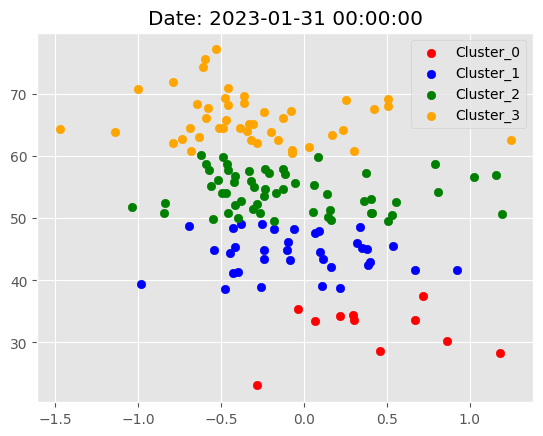

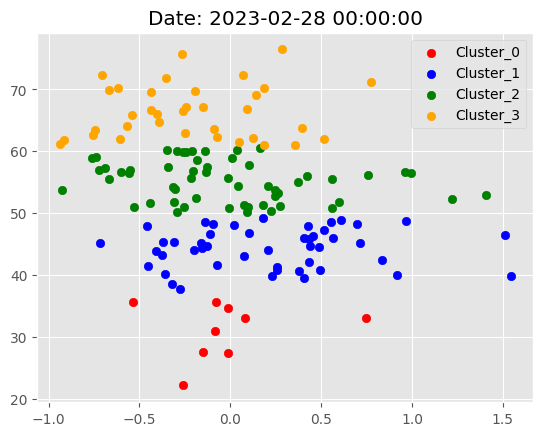

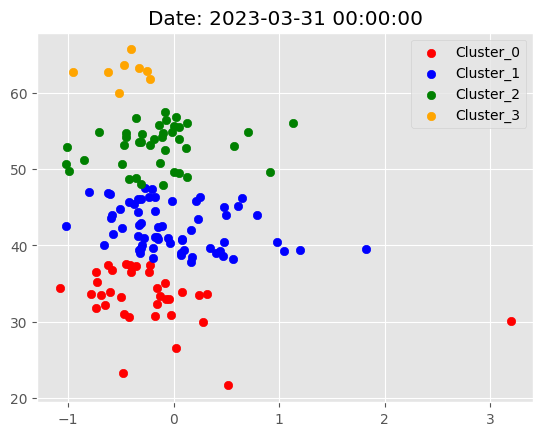

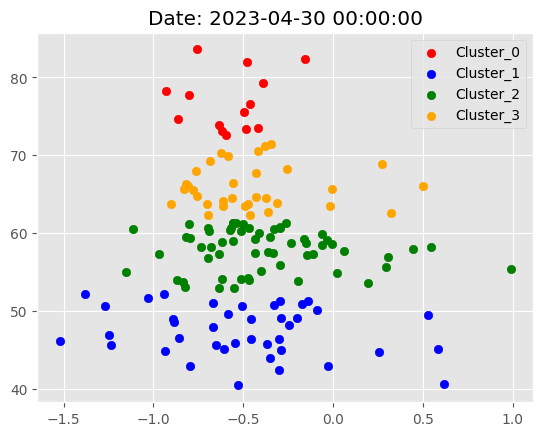

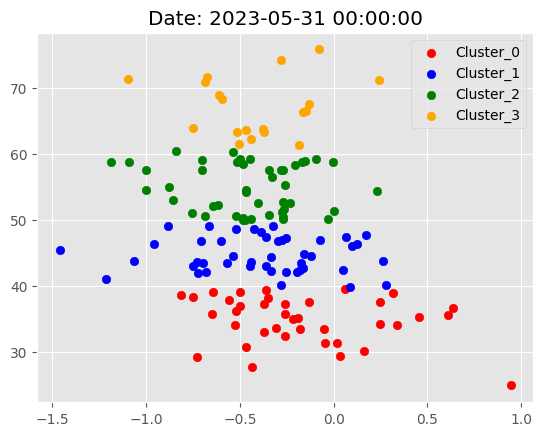

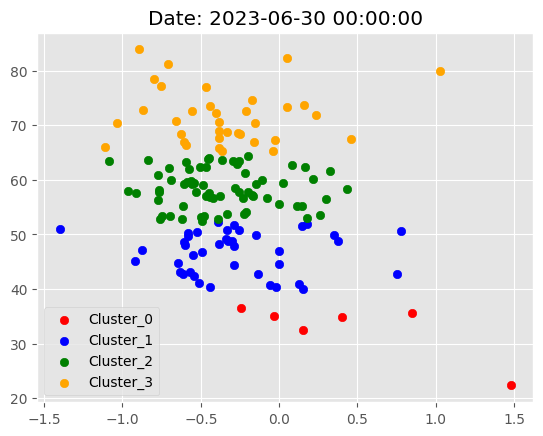

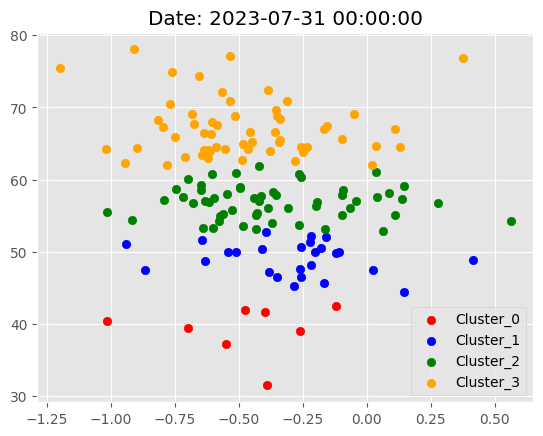

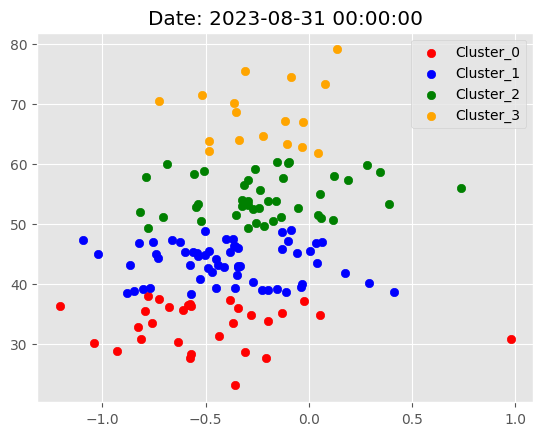

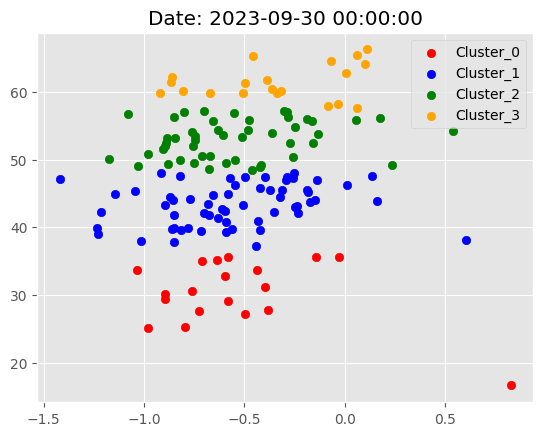

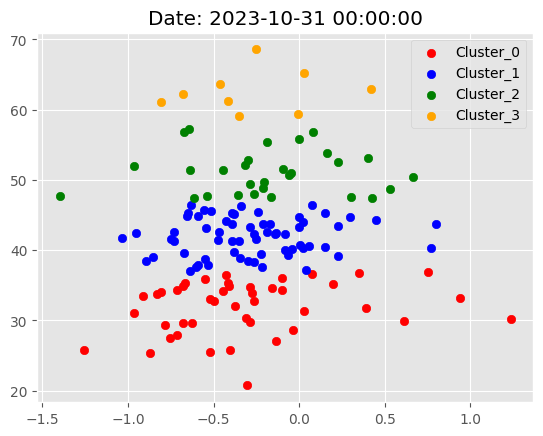

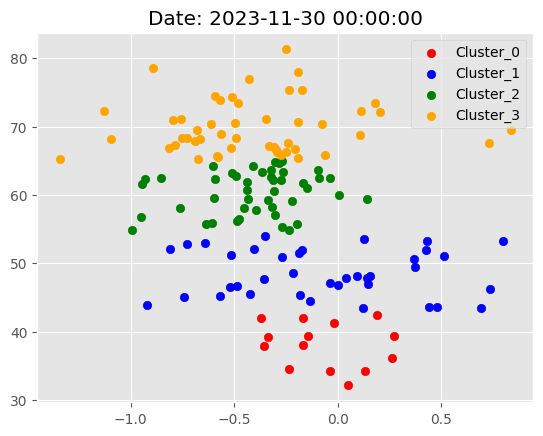

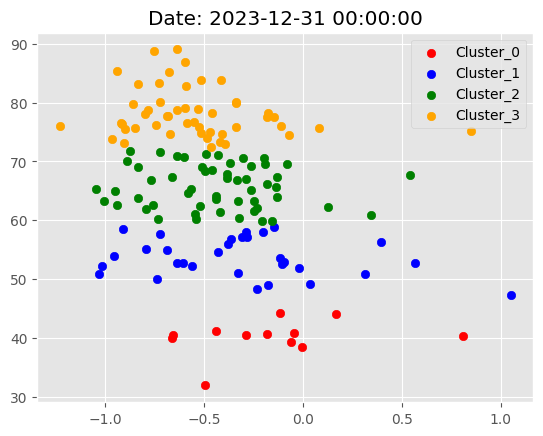

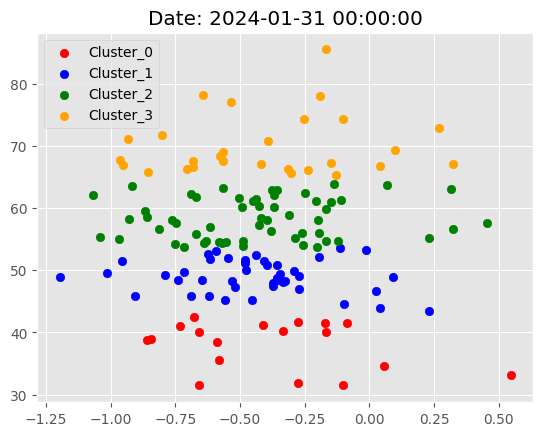

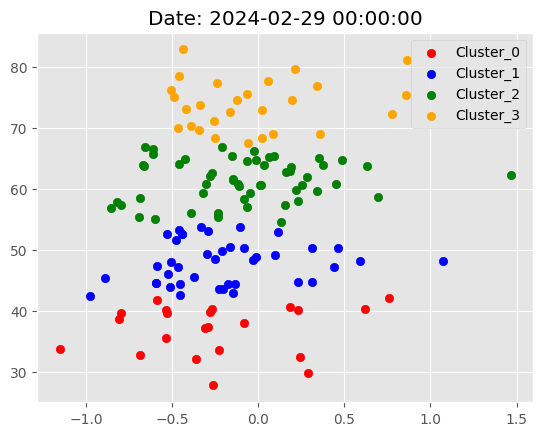

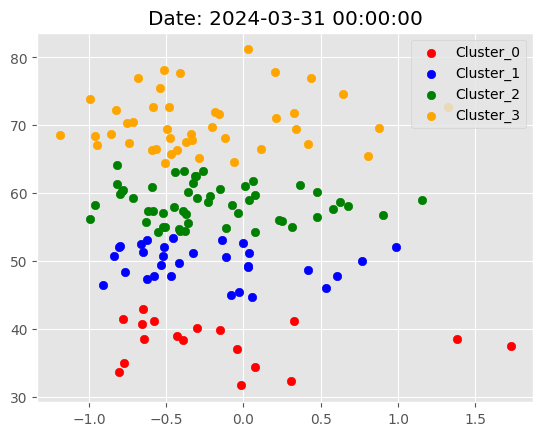

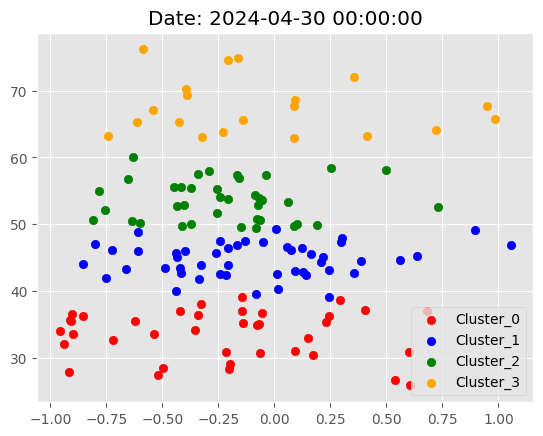

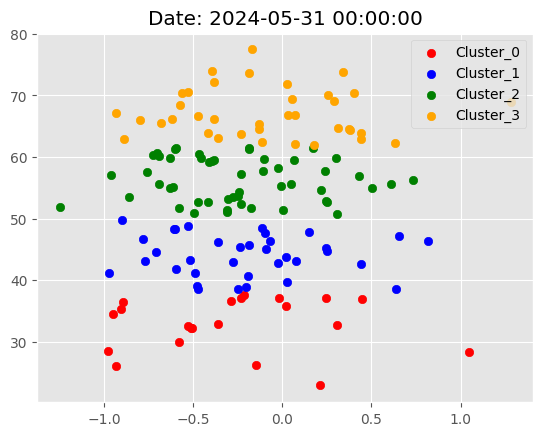

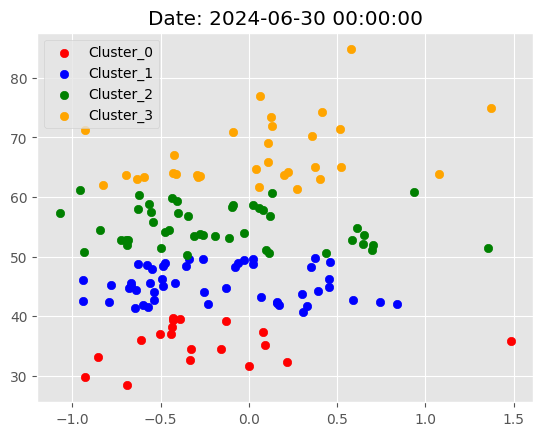

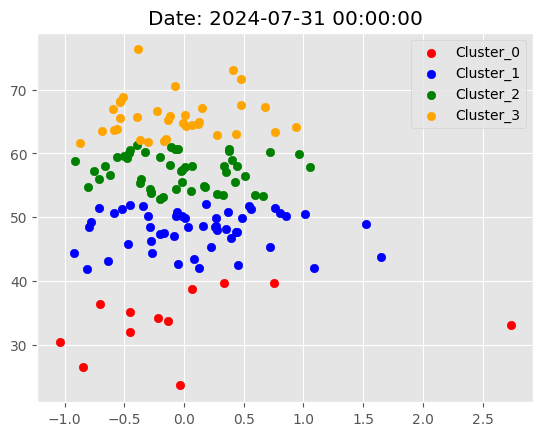

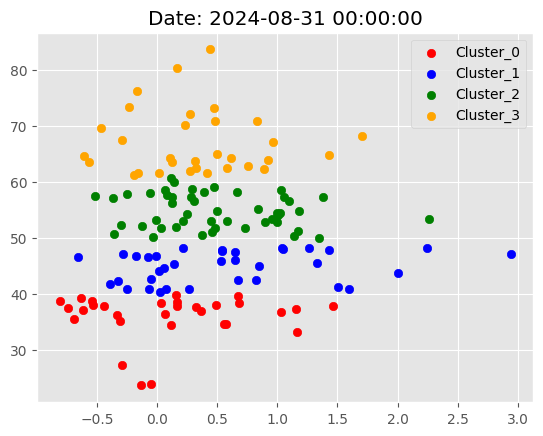

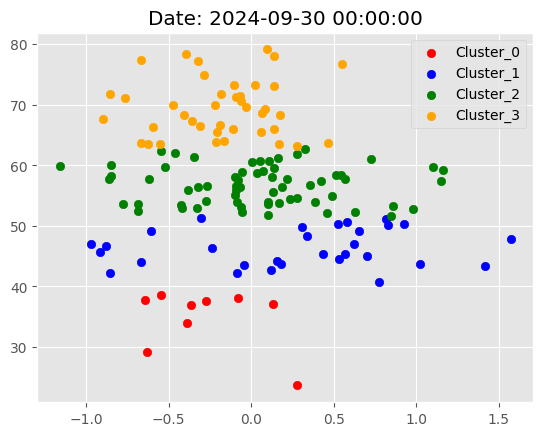

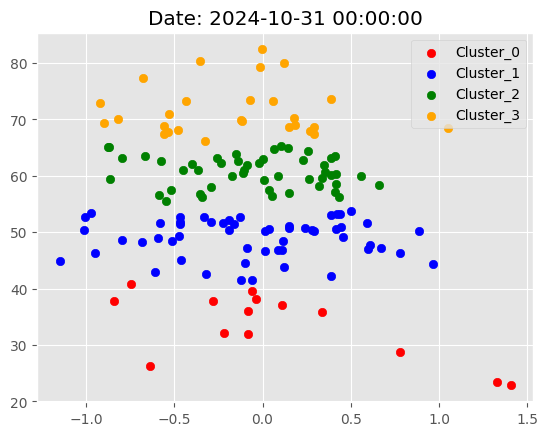

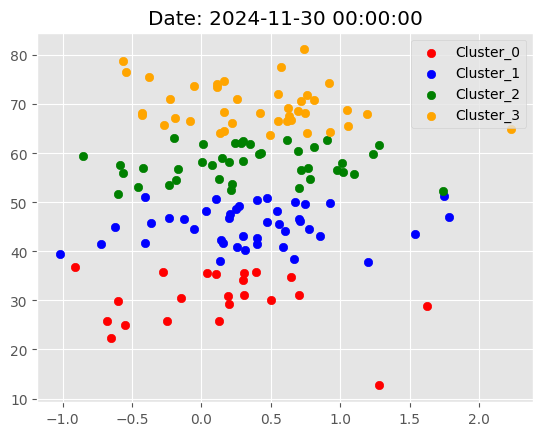

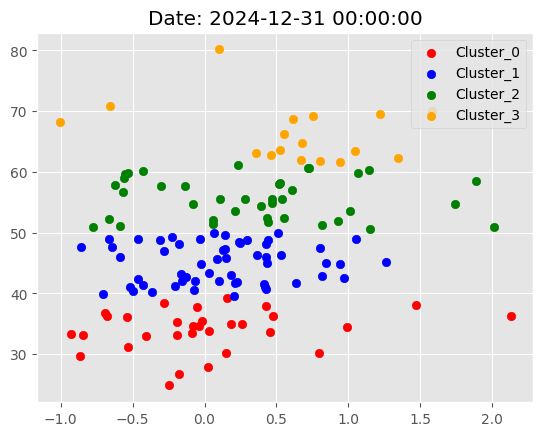

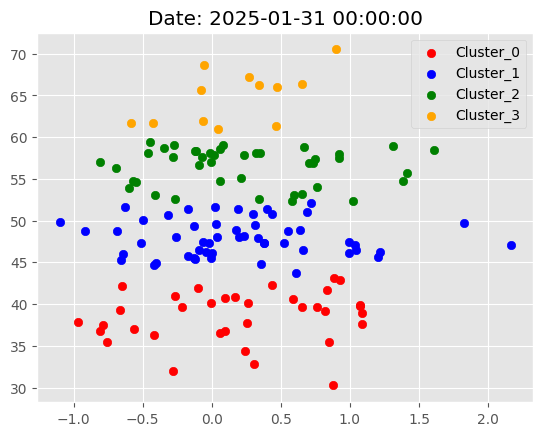

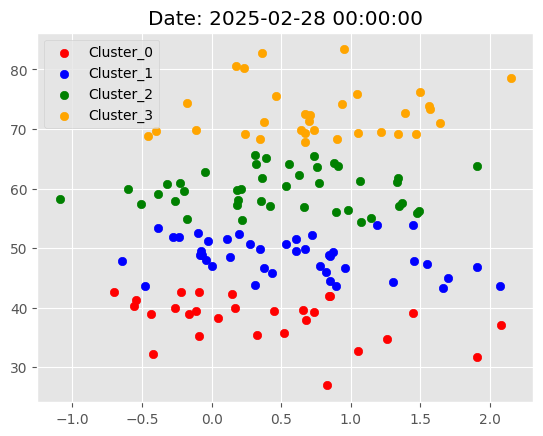

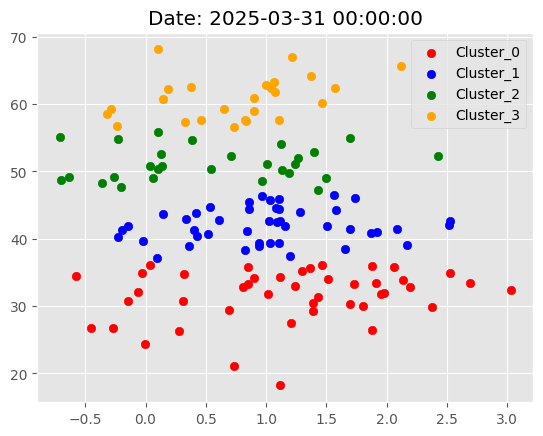

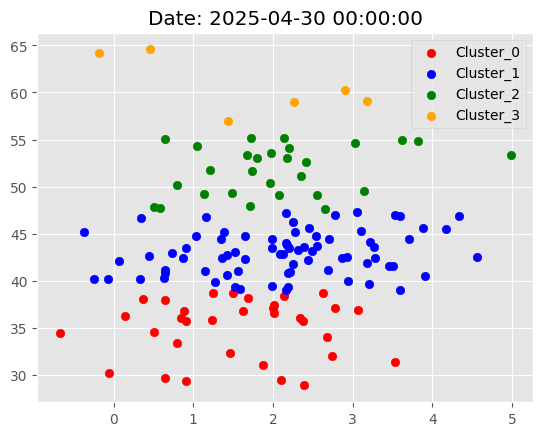

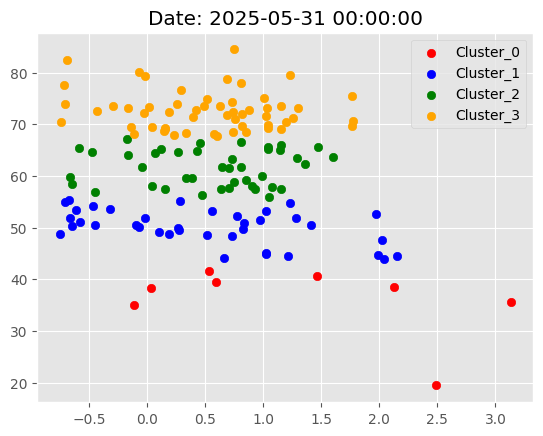

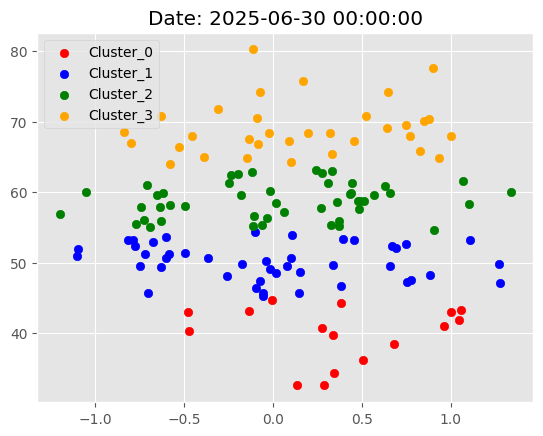

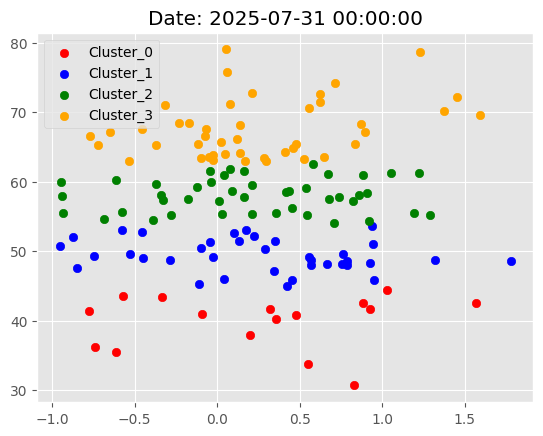

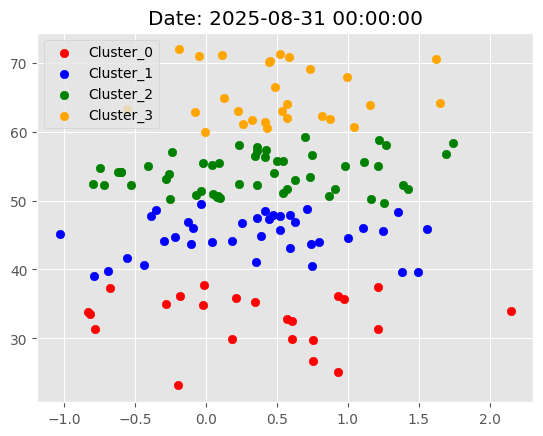

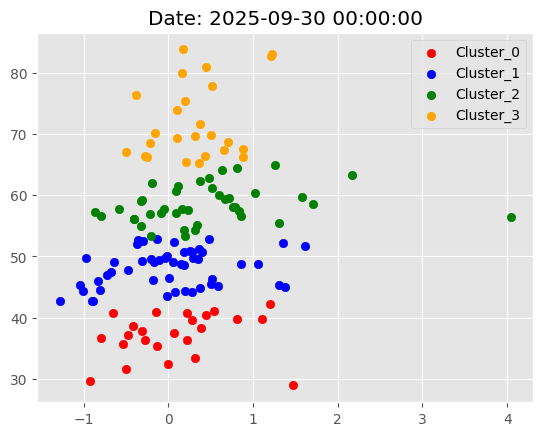

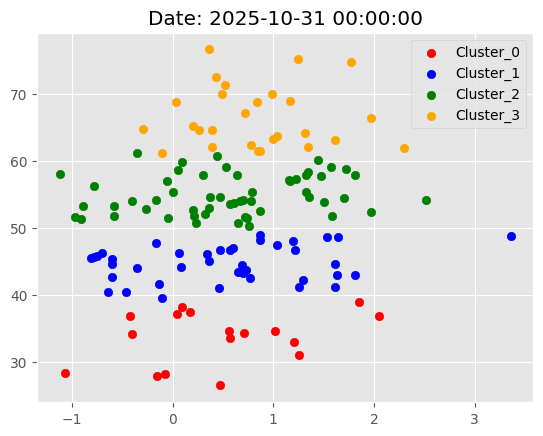

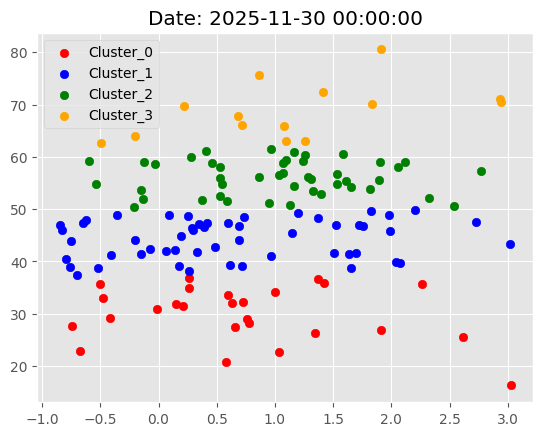

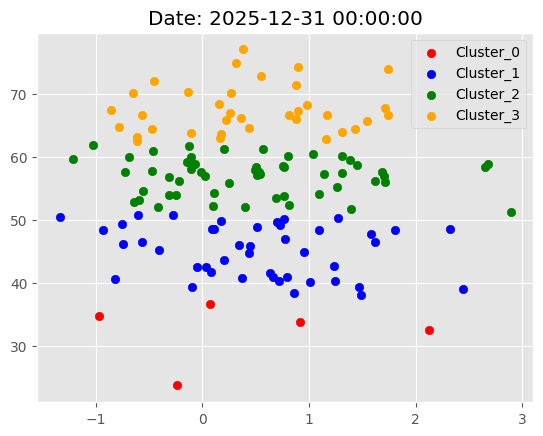

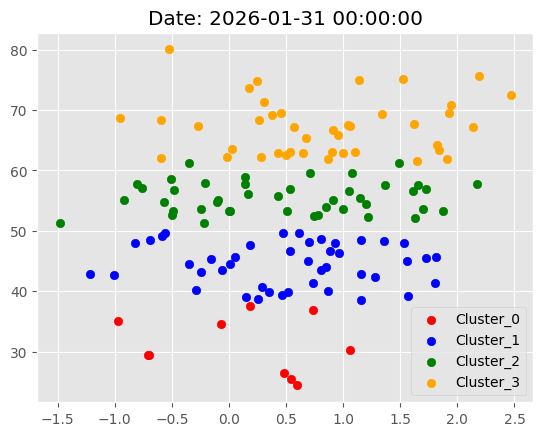

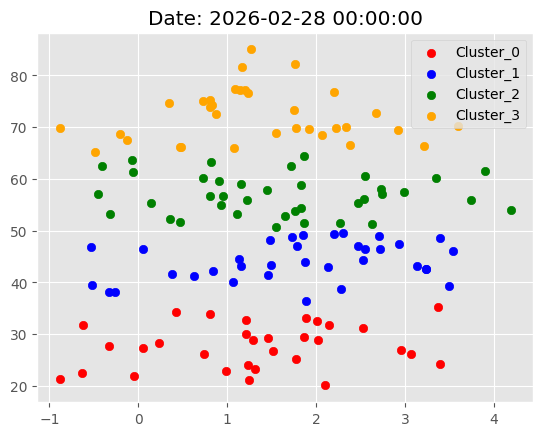

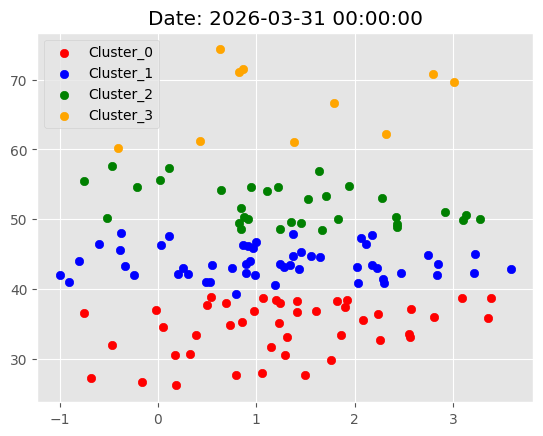

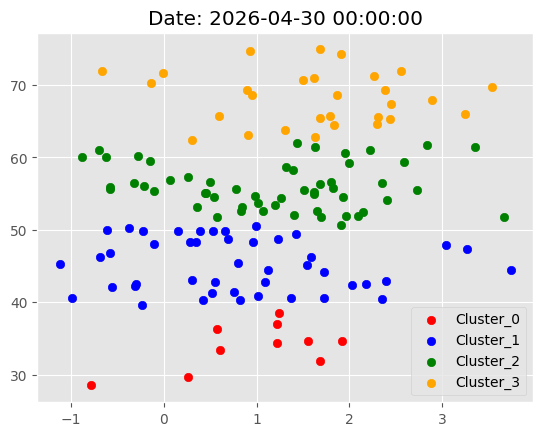

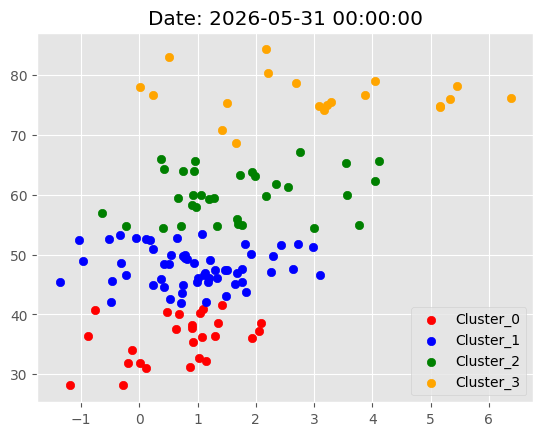

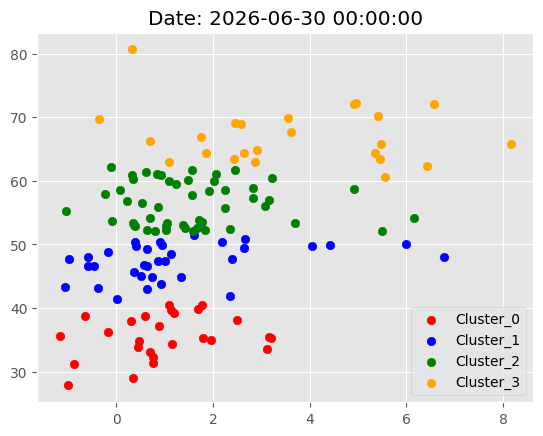

In [24]:

plt.style.use('ggplot')
for i in data.index.get_level_values(0).unique().to_list():
    g=data.xs(i,level=0)

    plt.title(f'Date: {i}' )

    plot_clusters(g)

In [ ]:


target_rsi_values =[30,45,55,70]

initial_centroids = np.zeros((4,18))

initial_centroids[:,1] = target_rsi_values
initial_centroids

array([[ 0., 30.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

In [ ]:
#Filtering the data to only include stocks in cluster 3

filter_df = data[data['Cluster'] == 3]
filter_df= filter_df.reset_index(level=1)

filter_df.index = filter_df.index+pd.DateOffset(1) 
filter_df = filter_df.reset_index().set_index(['Date','Ticker'])

dates = filter_df.index.get_level_values(0).unique().to_list()

fixed_dates={}
for d in dates:
    fixed_dates[d.strftime('%Y-%m-%d')] = filter_df.xs(d,level=0).index.get_level_values(0).unique().to_list()

fixed_dates

{'2020-06-01': ['AAPL',
  'CMG',
  'EBAY',
  'HD',
  'LOW',
  'META',
  'NOW',
  'PANW',
  'PYPL',
  'XYZ'],
 '2020-07-01': ['AAPL',
  'ABBV',
  'ACN',
  'ADBE',
  'ADSK',
  'ALGN',
  'AMAT',
  'AMT',
  'AMZN',
  'AVGO',
  'BA',
  'BLK',
  'CAT',
  'DAL',
  'DD',
  'DE',
  'DHR',
  'EA',
  'EBAY',
  'EL',
  'F',
  'FDX',
  'LIN',
  'LOW',
  'LRCX',
  'LULU',
  'MO',
  'MS',
  'MSFT',
  'NKE',
  'NVDA',
  'PYPL',
  'QCOM',
  'SPGI',
  'TMUS',
  'TSLA',
  'TXN',
  'UAL',
  'UPS',
  'WDAY',
  'XYZ'],
 '2020-08-01': ['AAPL',
  'ABT',
  'AMGN',
  'AMZN',
  'BDX',
  'COST',
  'DE',
  'DHR',
  'EA',
  'EBAY',
  'FDX',
  'LIN',
  'LOW',
  'LRCX',
  'PG',
  'TMO',
  'TSLA',
  'UPS',
  'WMT',
  'XYZ'],
 '2020-09-01': ['AAPL',
  'ACN',
  'AMD',
  'BRK-B',
  'CHTR',
  'COST',
  'DE',
  'DHR',
  'DIS',
  'EL',
  'FDX',
  'HD',
  'LOW',
  'LULU',
  'MA',
  'MCD',
  'MDLZ',
  'MRK',
  'NKE',
  'NOC',
  'NSC',
  'NVDA',
  'PG',
  'QCOM',
  'SHW',
  'TGT',
  'TMUS',
  'UPS',
  'VZ'],
 '2020-10-01': ['A

In [ ]:
#Optimizing the weights of the stocks in cluster 3 using PyPortfolioOpt

"""
    Uses Modern Portfolio Theory (MPT) to allocate weights
    among the selected stocks.

    Input:
        prices -> historical price dataframe of selected stocks

    Output:
        dictionary of optimized portfolio weights

    Goal:
        Maximize portfolio Sharpe Ratio
        while respecting weight constraints.
    """

from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

def optimize_weights(prices, lower_bound=0):
    
     # Estimate annualized expected returns from historical prices
    returns = expected_returns.mean_historical_return(prices=prices,
                                                      frequency=252)
    
    # Estimate annualized covariance matrix (portfolio risk)
    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)
    
    
    ef = EfficientFrontier(expected_returns=returns,
                           cov_matrix=cov,
                           weight_bounds=(lower_bound, .1),
                           solver='SCS')
    
    # Find portfolio with highest risk-adjusted return
    # Sharpe = (Return - RiskFreeRate) / Volatility
    weights = ef.max_sharpe()
    
    return ef.clean_weights()

In [ ]:

stocks = data.index.get_level_values('Ticker').unique().tolist()

new_df = yf.download(tickers=stocks,
                     start=data.index.get_level_values('Date').unique()[0]-pd.DateOffset(months=12),
                     end=data.index.get_level_values('Date').unique()[-1],
                     auto_adjust=False)

new_df

[*********************100%***********************]  164 of 164 completed


Price        Adj Close                                                 \
Ticker            AAPL        ABBV        ABNB        ABT         ACN   
Date                                                                    
2019-05-31   41.877136   57.129436         NaN  67.184052  161.063324   
2019-06-03   41.453735   56.377247         NaN  66.813416  158.431183   
2019-06-04   42.970287   57.159229         NaN  68.357750  160.972870   
2019-06-05   43.663975   57.390095         NaN  69.443237  162.411011   
2019-06-06   44.305027   57.397545         NaN  70.678719  163.170746   
...                ...         ...         ...        ...         ...   
2026-06-08  301.540009  223.070007  134.429993  90.500000  174.429993   
2026-06-09  290.549988  225.419998  131.350006  91.250000  173.470001   
2026-06-10  291.579987  224.949997  129.100006  89.169998  170.500000   
2026-06-11  295.630005  224.770004  130.869995  89.650002  167.520004   
2026-06-12  291.130005  227.729996  132.279999  88.180000  170.279999   

Price                                                                   ...  \
Ticker            ADBE         ADI         ADP        ADSK        ALGN  ...   
Date                                                                    ...   
2019-05-31  270.899994   85.407921  136.613312  160.910004  284.350006  ...   
2019-06-03  259.029999   84.921761  133.098160  154.820007  283.320007  ...   
2019-06-04  268.709991   89.253159  136.041672  159.910004  297.239990  ...   
2019-06-05  272.859985   88.280800  138.771881  161.309998  302.570007  ...   
2019-06-06  274.799988   88.369186  140.179626  161.160004  306.359985  ...   
...                ...         ...         ...         ...         ...  ...   
2026-06-08  244.990005  403.890015  227.355072  225.039993  172.050003  ...   
2026-06-09  237.880005  404.619995  229.429337  224.080002  178.100006  ...   
2026-06-10  233.380005  392.670013  229.359863  221.279999  170.500000  ...   
2026-06-11  218.800003  412.130005  224.070007  205.570007  176.509995  ...   
2026-06-12  204.020004  417.790009  226.210007  198.429993  174.839996  ...   

Price        Volume                                                           \
Ticker          VLO     VRTX        VZ     WDAY      WDC       WFC       WMT   
Date                                                                           
2019-05-31  5670700   982500  29916600  1721300  9421480  17540500  17782500   
2019-06-03  3760600  1080600  19518300  2941300  7521255  20172500  19844100   
2019-06-04  3135000  1456800  15201200  3164100  7154784  21082000  17894700   
2019-06-05  3245400  1254500  11522900  2095200  6689882  13705400  20708700   
2019-06-06  3767900  1261100   9906900  1320400  6533239  16020500  24191100   
...             ...      ...       ...      ...      ...       ...       ...   
2026-06-08  3043200  1149300  18994700  2952800  6226300  11481200  19514100   
2026-06-09  2724400   871200  24758100  5214100  7278700  15565500  23959000   
2026-06-10  2522900  1103200  25239500  3474100  5978300  12580800  22414900   
2026-06-11  3365200  1233800  26889400  5880800  6334600  10929900  22438000   
2026-06-12  2202700   924200  21954500  6670400  6285300  10524600  14753500   

Price                                   
Ticker         WYNN       XOM      XYZ  
Date                                    
2019-05-31  2892700  13983300  7220500  
2019-06-03  2661700  11831000  9309700  
2019-06-04  3236300  10423000  8234400  
2019-06-05  2106800  10617800  9330700  
2019-06-06  1589100  11738900  6021800  
...             ...       ...      ...  
2026-06-08  1047300  13870900  5792700  
2026-06-09  2408300  18163500  5407800  
2026-06-10  1438300  14596500  3795400  
2026-06-11  1952700  17285800  5934200  
2026-06-12  1325600  17710400  4631500  

[1769 rows x 984 columns]

In [ ]:
#


returns_dataframe = np.log(new_df['Adj Close']).diff()

# Store strategy returns generated during backtest
portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():
    
    try:

        end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')

        cols = fixed_dates[start_date]

        
        # Use previous 12 months of data for optimization
        # (avoid look-ahead bias)

        optimization_start_date = (pd.to_datetime(start_date)-pd.DateOffset(months=12)).strftime('%Y-%m-%d')

        optimization_end_date = (pd.to_datetime(start_date)-pd.DateOffset(days=1)).strftime('%Y-%m-%d')
        
        optimization_df = new_df[optimization_start_date:optimization_end_date]['Adj Close'][cols]
        
        success = False

         # Find optimal portfolio weights
         # by maximizing Sharpe ratio
        try:
            weights = optimize_weights(prices=optimization_df,
                                   lower_bound=round(1/(len(optimization_df.columns)*2),3))

            weights = pd.DataFrame(weights, index=pd.Series(0))
            
            success = True
        except:
             # Fallback if optimizer fails
            print(f'Max Sharpe Optimization failed for {start_date}, Continuing with Equal-Weights')
        
        if success==False:
            weights = pd.DataFrame([1/len(optimization_df.columns) for i in range(len(optimization_df.columns))],
                                     index=optimization_df.columns.tolist(),
                                     columns=pd.Series(0)).T
        
         # Daily returns during holding period
        temp_df = returns_dataframe[start_date:end_date]

         # Convert returns into long format
         # and attach portfolio weights
        temp_df = temp_df.stack().to_frame('return').reset_index(level=0)\
                   .merge(weights.stack().to_frame('weight').reset_index(level=0, drop=True),
                          left_index=True,
                          right_index=True)\
                   .reset_index().set_index(['Date', 'Ticker']).unstack().stack()

        temp_df.index.names = ['Date', 'Ticker']

        temp_df['weighted_return'] = temp_df['return']*temp_df['weight']

        temp_df = temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')

        portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)
    
    except Exception as e:
        print(e)

portfolio_df = portfolio_df.drop_duplicates()

portfolio_df

Max Sharpe Optimization failed for 2022-06-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2022-10-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2023-04-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2023-11-01, Continuing with Equal-Weights
Max Sharpe Optimization failed for 2025-05-01, Continuing with Equal-Weights
'return'


,Strategy Return
Date,
2020-06-01,0.008265
2020-06-02,0.018960
2020-06-03,0.000158
2020-06-04,-0.013231
2020-06-05,0.017894
...,...
2026-06-08,0.021118
2026-06-09,-0.014838
2026-06-10,-0.021874


In [61]:
spy = yf.download(
    tickers='SPY',
    start='2019-05-31',
    end=dt.date.today(),
    auto_adjust=False
)

spy_ret = np.log(spy['Adj Close']).diff().dropna()

spy_ret.columns = ['SPY Buy&Hold']

portfolio_df = portfolio_df.join(
    spy_ret,
    how='inner'
)

portfolio_df

[*********************100%***********************]  1 of 1 completed


,Strategy Return,SPY Buy&Hold
Date,,
2020-06-01,0.008265,0.004034
2020-06-02,0.018960,0.008246
2020-06-03,0.000158,0.013220
2020-06-04,-0.013231,-0.002630
2020-06-05,0.017894,0.025306
...,...,...
2026-06-08,0.021118,0.002262
2026-06-09,-0.014838,-0.002940
2026-06-10,-0.021874,-0.015891


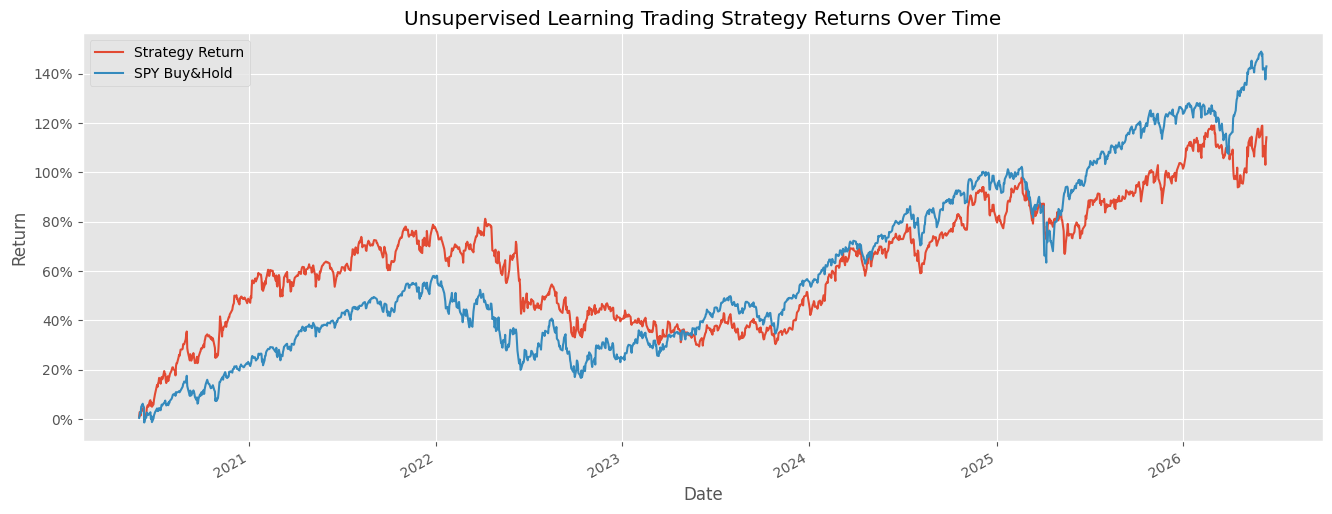

In [62]:

import matplotlib.ticker as mtick

plt.style.use('ggplot')

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum())-1

portfolio_cumulative_return[:'2026-06-12'].plot(figsize=(16,6))

plt.title('Unsupervised Learning Trading Strategy Returns Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()
